8/22: This was resolved by fixing the expression for $G_r$, which attributed complex conjugates incorrectly. Moving to archived.

Oh boy, 

So basically I think theres a chance that a lot of floating complex numbers may have been mmsising.

I really need to relook ata ll my equations and make sure they're right...

For sure, I noticed that the matrix made in sigma_general is not complex (why would it be i thought naively) but now im seeing stuff and odn't know if its physical or not.

In [1]:
import sys
sys.path.append("../../src/")
import kibble_zurek as kz
import numpy as np
from numpy import cos, sin, exp, pi,sqrt
import matplotlib.pyplot as plt
from matplotlib.pyplot import plot, scatter, loglog, xlim, ylim, xlabel, ylabel, loglog, show,legend,yscale,xscale
from time import time
from scipy.optimize import curve_fit

import numpy as np
from numpy import cos, sin, exp, pi, sqrt, abs
from mpmath import pcfd
import kblock_ising_model as kb
from itertools import combinations
from collections import Counter
import mpmath as mp

mp.mp.dps = 50   

In [2]:
import cmath

def cmath_v_tilde(tau,q,t):
    """tau = quench time
    tf  =final time
    q   =momentum value
    eq. 7.2.88"""
    a = 1+cos(q)
    b = sin(q)
    
    rot = cmath.exp(-1j*3*pi/4)
    rot_inv = cmath.exp(1j*3*pi/4)
    decay = cmath.exp(-pi*b*b*tau/4)
    prefactor = -decay
    argument = rot_inv*2*(t-a*tau)/cmath.sqrt(tau)
    nu = 1j*b*b*tau
    #Can be unstable at large tau
    return prefactor*complex(pcfd(nu,argument))

In [3]:

def u_tilde(tau,q,tf):
    """tau = quench time
    tf  =final time
    q   =momentum value
    eq. 7.2.87"""
    a = 1+cos(q)
    b = sin(q)

    rot = exp(-1j*3*pi/4)
    decay = exp(-pi*b*b*tau/4)
    prefactor = rot*b*sqrt(tau)*decay
    argument = 1/rot*2*(tf-a*tau)/sqrt(tau)
    nu = 1j*b*b*tau-1
    #Can be unstable at large tau
    return prefactor*complex(pcfd(nu,argument))

def v_tilde(tau,q,t):
    """tau = quench time
    tf  =final time
    q   =momentum value
    eq. 7.2.88"""
    a = 1+cos(q)
    b = sin(q)
    
    rot = exp(-1j*3*pi/4)
    rot_inv = exp(1j*3*pi/4)
    decay = exp(-pi*b*b*tau/4)
    prefactor = -decay
    argument = rot_inv*2*(t-a*tau)/sqrt(tau)
    nu = 1j*b*b*tau
    #Can be unstable at large tau
    return prefactor*complex(pcfd(nu,argument))

In [4]:
################################################
#           FULL SYSTEM SOLUTIONS
################################################
def k_vals(L):
    """Generates k values >0"""
    x=(2 * np.arange(-L//2, L//2) + 1) * np.pi / (L)
    return x[x>0]


def state(L,tau,t):
    """Generates state as [us, vs, k]"""
    #Generate momentum values
    k = k_vals(L)
    us = np.array([u_tilde(tau,q,t) for q in k])
    vs = np.array([v_tilde(tau,q,t) for q in k])
    return [us,vs,k]

################################################
#           CORRELATION FUNCTIONS
################################################
def G(r, state):
    u, v, k = state  # arrays over q
    Gr = 2*np.cos(k*r)*(u**2 - v**2) - 2j*np.sin(k*r)*(u*np.conj(v) - v*np.conj(u))
    return -np.mean(Gr)  # or sum/N, consistent with your normalization
def G(r, state):
    u, v, k = state  # arrays over q>0
    s = np.abs(u)**2 + np.abs(v)**2
    u = u/np.sqrt(s); v = v/np.sqrt(s)
    Gr = 2*np.cos(k*r)*(np.abs(u)**2 - np.abs(v)**2) \
         - 4*np.sin(k*r)*np.imag(np.conj(u)*v)
    return -0.5*np.mean(Gr)



def D(n,state):
    """Strange Convention, n = r-1"""
    r = n+1
    return G(r,state)

In [5]:
taus =np.logspace(-2,2,100)
k= k_vals(L=100)

In [6]:
states= [kz.state(100,tau,tau) for tau in taus]

In [7]:
R=[]
I=[]
x= []
for s in states:
    g= kz.G(1,s)
    R.append(np.real(g))
    I.append(np.imag(g))
    x.append(np.abs(g))

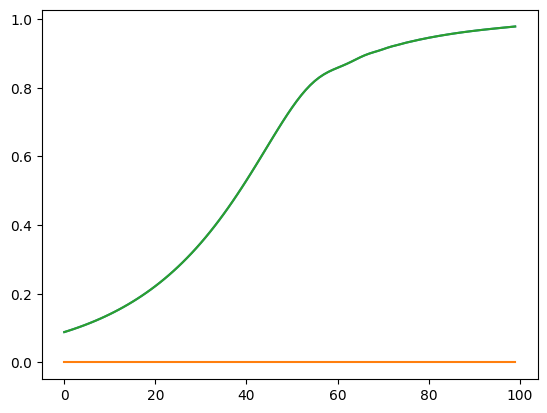

In [8]:
plot(R)
plot(I)
plot(x)

In [15]:
def G(r,state):
    """r = integer
    state = [us, vs, k]
    calculates {bi,aj} correlation of r=j-i
    """
    u = state[0]
    v = state[1]
    k = state[2]
    #Equation 7.2.26a
    Gr = 2*cos(k*r)*(np.abs(u)**2-np.abs(v)**2)-2j*sin(k*r)*(np.conj(u)*v+v*np.conj(u))
    return -np.mean(Gr)/2

In [19]:
kz.G(-1,s)

np.complex128(-0.022427238413402027+0j)

In [23]:
print([kz.G(i,s)==np.real(G(i,s)) for i in np.arange(-30,30)])

[np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_]
